# Análise de Redes Sociais da Insegurança Alimentar no Brasil

# 1. Coleta dos dados

In [1]:
# Impotando os dados
caminho_salvar <- "C:/Users/mauri/Downloads/Dados_POF_2017-2018/dados_final_dummys.csv"
dados_final_dummys <- read.csv2(caminho_salvar)
head(as.data.frame(dados_final_dummys), 5)

,RECEBE_BOLSA_FAMILIA,SEGURANCA_ALIMENTAR,IA_BINARIA,IS_SEGURA,IS_LEVE,IS_MODERADA,IS_GRAVE,RENDA_PER_CAPITA,IDADE,QUANTIDADE_COMODOS,⋯,REGIAO_SUL,REGIAO_CENTRO,EDUC_BAIXA,EDUC_MEDIA,EDUC_ALTA,AGUA_REDE,LUZ_REDE,PAREDE_SOLIDA,FOGAO_LENHA,ALUGADO
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,1,0,1,0,0,0,1237.183,64,6,⋯,0,0,1,0,0,1,1,1,0,0
2,0,4,1,0,0,0,1,1317.677,65,5,⋯,0,0,1,0,0,1,1,1,0,1
3,1,1,0,1,0,0,0,1965.761,45,9,⋯,0,0,0,0,1,0,1,1,0,1
4,0,1,0,1,0,0,0,1083.509,37,8,⋯,0,0,0,0,1,1,1,1,0,1
5,0,1,0,1,0,0,0,2472.565,48,8,⋯,0,0,0,0,1,0,1,1,0,1


# 2. Estrutura dos dados

In [2]:
str(dados_final_dummys)

'data.frame':	52139 obs. of  28 variables:
 $ RECEBE_BOLSA_FAMILIA: int  0 0 1 0 0 1 0 1 0 0 ...
 $ SEGURANCA_ALIMENTAR : int  1 4 1 1 1 2 1 1 1 2 ...
 $ IA_BINARIA          : int  0 1 0 0 0 1 0 0 0 1 ...
 $ IS_SEGURA           : int  1 0 1 1 1 0 1 1 1 0 ...
 $ IS_LEVE             : int  0 0 0 0 0 1 0 0 0 1 ...
 $ IS_MODERADA         : int  0 0 0 0 0 0 0 0 0 0 ...
 $ IS_GRAVE            : int  0 1 0 0 0 0 0 0 0 0 ...
 $ RENDA_PER_CAPITA    : num  1237 1318 1966 1084 2473 ...
 $ IDADE               : int  64 65 45 37 48 39 71 24 53 56 ...
 $ QUANTIDADE_COMODOS  : int  6 5 9 8 8 5 4 6 7 8 ...
 $ MULHER              : int  0 1 1 0 0 1 1 0 1 1 ...
 $ RACA_PRETA          : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RACA_PARDA          : int  1 1 1 1 1 1 1 1 1 0 ...
 $ RACA_AMARELA        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RACA_INDIGENA       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ URBANO              : int  1 1 1 1 1 1 1 1 1 1 ...
 $ REGIAO_NORTE        : int  1 1 1 1 1 1 1 1 1 1 ...
 $ REGIAO_SUDESTE      :

# 3. Preparação da base de dados

In [ ]:
# =========================
# Preparação
# =========================

library(dplyr)
library(Matrix)
library(igraph)
library(ggraph)
library(ggplot2)

# Criar ID observacional
dados_ars <- dados_final_dummys %>%
  mutate(id_obs = row_number())


Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union



Anexando pacote: 'igraph'


Os seguintes objetos são mascarados por 'package:dplyr':

    as_data_frame, groups, union


Os seguintes objetos são mascarados por 'package:stats':

    decompose, spectrum


O seguinte objeto é mascarado por 'package:base':

    union


Carregando pacotes exigidos: ggplot2



# 4. Seleção das Variáveis para a Rede

In [ ]:
# =========================
# Seleção das variáveis
# =========================

vars_rede <- c(
  "IS_LEVE",
  "IS_MODERADA",
  "IS_GRAVE",
  "MULHER",
  "RACA_PRETA",
  "RACA_PARDA",
  "EDUC_BAIXA",
  "RENDA_PER_CAPITA",
  "ALUGADO",
  "FOGAO_LENHA",
  "AGUA_REDE",
  "LUZ_REDE",
  "PAREDE_SOLIDA"
)

# Criar indicador de renda baixa (1º quintil)
dados_ars <- dados_ars %>%
  mutate(
    renda_quintil = ntile(RENDA_PER_CAPITA, 5),
    RENDA_BAIXA = ifelse(renda_quintil == 1, 1, 0)
  )

vars_rede <- c(
  "IS_LEVE",
  "IS_MODERADA",
  "IS_GRAVE",
  "MULHER",
  "RACA_PRETA",
  "RACA_PARDA",
  "EDUC_BAIXA",
  "RENDA_BAIXA",
  "ALUGADO",
  "FOGAO_LENHA",
  "AGUA_REDE",
  "LUZ_REDE",
  "PAREDE_SOLIDA"
)

# 5. Construção da Matriz de Coocorrência (X'X)

In [ ]:
# =========================
# Matriz de coocorrência
# =========================

library(tidyr)

dados_rede <- dados_ars %>%
  select(id_obs, all_of(vars_rede)) %>%
  drop_na()

X <- as.matrix(dados_rede %>% select(all_of(vars_rede)))
Xs <- Matrix(X, sparse = TRUE)

# Produto matricial
A <- Matrix::crossprod(Xs)

# Remover diagonal
diag(A) <- 0

A_dense <- as.matrix(A)
colnames(A_dense) <- vars_rede
rownames(A_dense) <- vars_rede


Anexando pacote: 'tidyr'


O seguinte objeto é mascarado por 'package:igraph':

    crossing


Os seguintes objetos são mascarados por 'package:Matrix':

    expand, pack, unpack




# 6. Construção do Grafo

In [ ]:
# =========================
# Construção do grafo
# =========================

min_weight <- 1000  # ajuste conforme densidade desejada

inds <- which(A_dense >= min_weight, arr.ind = TRUE)

edges <- data.frame(
  from = rownames(A_dense)[inds[,1]],
  to   = colnames(A_dense)[inds[,2]],
  weight = A_dense[inds]
) %>%
  filter(from < to)

g_ia <- graph_from_data_frame(edges,
                              directed = FALSE,
                              vertices = data.frame(name = vars_rede))

E(g_ia)$weight <- edges$weight

g_ia

IGRAPH 27ac07e UNW- 13 72 -- 
+ attr: name (v/c), weight (e/n)
+ edges from 27ac07e (vertex names):
 [1] IS_LEVE    --EDUC_BAIXA  IS_LEVE    --ALUGADO     IS_LEVE    --FOGAO_LENHA
 [4] IS_LEVE    --AGUA_REDE   IS_MODERADA--EDUC_BAIXA  IS_MODERADA--ALUGADO    
 [7] IS_MODERADA--FOGAO_LENHA IS_MODERADA--AGUA_REDE   IS_GRAVE   --EDUC_BAIXA 
[10] IS_GRAVE   --ALUGADO     IS_GRAVE   --FOGAO_LENHA IS_GRAVE   --AGUA_REDE  
[13] IS_LEVE    --MULHER      IS_MODERADA--MULHER      IS_GRAVE   --MULHER     
[16] MULHER     --EDUC_BAIXA  MULHER     --ALUGADO     MULHER     --FOGAO_LENHA
[19] MULHER     --AGUA_REDE   MULHER     --LUZ_REDE    IS_LEVE    --RACA_PRETA 
[22] MULHER     --RACA_PRETA  RACA_PRETA --EDUC_BAIXA  RACA_PRETA --ALUGADO    
+ ... omitted several edges

# 7. Métricas Estruturais Globais

In [8]:
# =========================
# Métricas globais
# =========================

E(g_ia)$dist <- 1 / E(g_ia)$weight

metricas_rede <- data.frame(
  nodes = vcount(g_ia),
  edges = gsize(g_ia),
  density = edge_density(g_ia),
  components = components(g_ia)$no,
  modularity_louvain = modularity(cluster_louvain(g_ia,
                                                  weights = E(g_ia)$weight))
)

metricas_rede

nodes,edges,density,components,modularity_louvain
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13,72,0.9230769,1,0


# 8. Centralidades

In [9]:
# =========================
# Centralidades
# =========================

centralidades <- data.frame(
  node = V(g_ia)$name,
  strength = strength(g_ia, weights = E(g_ia)$weight),
  betweenness = betweenness(g_ia,
                            weights = E(g_ia)$dist,
                            normalized = TRUE),
  eigenvector = eigen_centrality(g_ia,
                                  weights = E(g_ia)$weight)$vector
)

centralidades %>%
  arrange(desc(strength))

,node,strength,betweenness,eigenvector
,<chr>,<dbl>,<dbl>,<dbl>
LUZ_REDE,LUZ_REDE,245377,0.6969697,1.00000000
PAREDE_SOLIDA,PAREDE_SOLIDA,227266,0.0000000,0.95225680
AGUA_REDE,AGUA_REDE,194903,0.0000000,0.85247155
ALUGADO,ALUGADO,182871,0.0000000,0.79498728
EDUC_BAIXA,EDUC_BAIXA,139723,0.0000000,0.60637126
RACA_PARDA,RACA_PARDA,135776,0.0000000,0.60640086
MULHER,MULHER,121314,0.0000000,0.54578149
FOGAO_LENHA,FOGAO_LENHA,74578,0.0000000,0.32444086
IS_LEVE,IS_LEVE,73646,0.0000000,0.33466421


# 9. Rede de Coocorrência da Insegurança Alimentar no Brasil

Warning message:
"The `trans` argument of `continuous_scale()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `transform` argument instead."


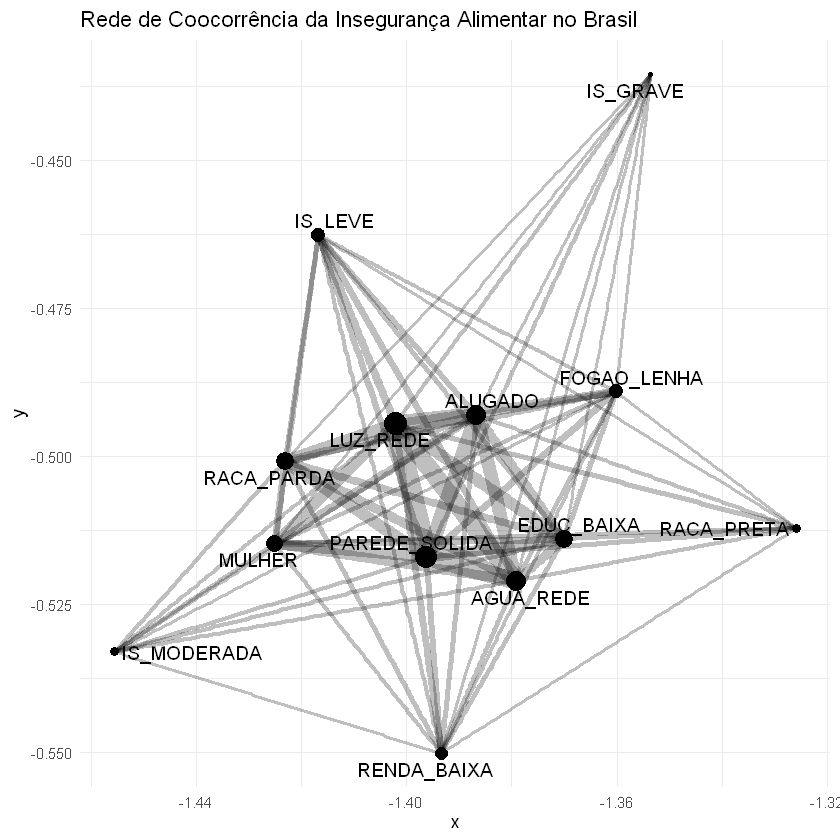

In [10]:
# =========================
# Visualização
# =========================

set.seed(123)

ggraph(g_ia, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.25) +
  geom_node_point(aes(size = strength(g_ia,
                                      weights = E(g_ia)$weight))) +
  geom_node_text(aes(label = name),
                 repel = TRUE,
                 size = 4) +
  theme_minimal() +
  guides(edge_width = "none", size = "none") +
  labs(title = "Rede de Coocorrência da Insegurança Alimentar no Brasil")

# 10. Comunidades (Louvain)

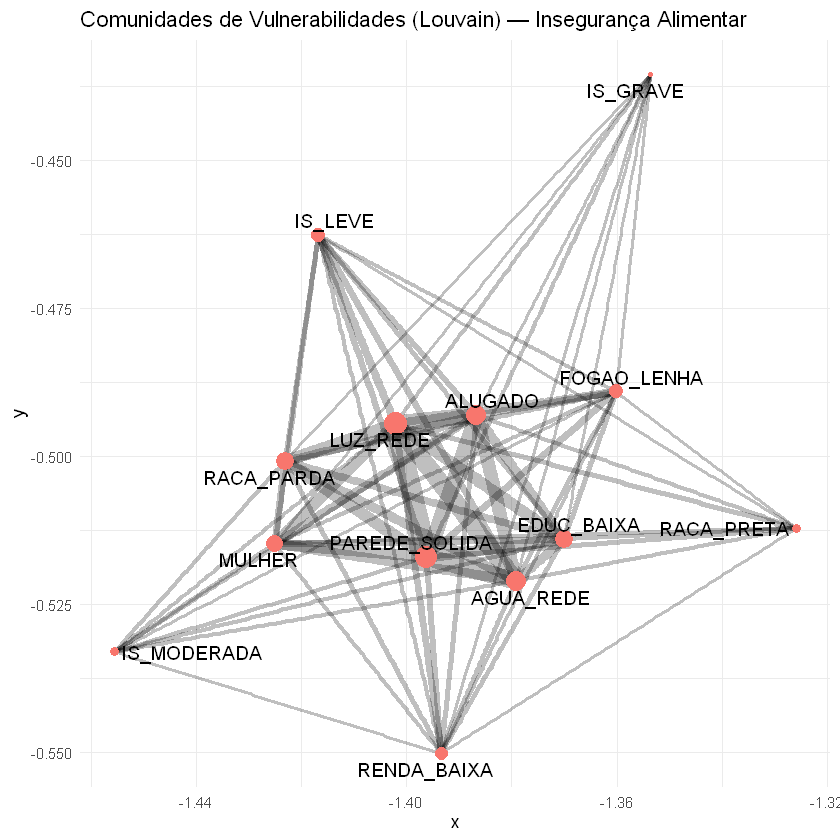

In [11]:
# =========================
# Comunidades Louvain
# =========================

cl <- cluster_louvain(g_ia,
                      weights = E(g_ia)$weight)

V(g_ia)$community <- as.factor(membership(cl))

set.seed(123)

ggraph(g_ia, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.25) +
  geom_node_point(aes(color = community,
                      size = strength(g_ia,
                                      weights = E(g_ia)$weight))) +
  geom_node_text(aes(label = name),
                 repel = TRUE,
                 size = 4) +
  theme_minimal() +
  guides(edge_width = "none",
         size = "none",
         color = "none") +
  labs(title = "Comunidades de Vulnerabilidades (Louvain) — Insegurança Alimentar")

# 11. Análises dos Resultados

In [ ]:
# ==========================================
# RESUMO DAS ANÁLISES — ARS INSEGURANÇA ALIMENTAR
# ==========================================

# • Foi construída uma rede de coocorrência entre 13 vulnerabilidades
#   socioeconômicas, incluindo insegurança alimentar (leve, moderada e grave),
#   renda baixa, escolaridade, raça, gênero e condições habitacionais.

# • A rede foi gerada a partir do produto matricial X'X (indivíduo × vulnerabilidade),
#   resultando em grafo não direcionado e ponderado.

# • Métricas estruturais globais:
#   - 13 nós
#   - 72 arestas
#   - Densidade = 0.92
#   - 1 componente conectado
#   - Modularidade (Louvain) = 0

# • A elevada densidade indica forte integração entre vulnerabilidades,
#   sugerindo que elas tendem a ocorrer simultaneamente.

# • Centralidades:
#   - LUZ_REDE apresentou maior força e maior centralidade de autovetor.
#   - PAREDE_SOLIDA e AGUA_REDE também ocupam posições centrais.
#   - RENDA_BAIXA aparece integrada ao núcleo estrutural.
#   - IS_GRAVE apresentou menor força e menor centralidade relativa.

# • A betweenness próxima de zero indica ausência de nós intermediadores
#   dominantes, reforçando o caráter altamente integrado da rede.

# • A detecção de comunidades via Louvain não identificou clusters bem
#   delimitados, indicando que as vulnerabilidades formam um sistema
#   relacional integrado e interdependente.